In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

In [3]:
connection_string = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

engine = create_engine(connection_string)

In [4]:
query = """
SELECT *
FROM monthly_performance
ORDER BY month;
"""

df = pd.read_sql(query, engine)

df.head()

,month,total_transactions,total_transaction_value,average_transaction_value,active_customers,previous_month_value,previous_year_value,rolling_3_month_average,mom_growth_percent,yoy_growth_percent
0,2024-01-01 00:00:00-05:00,2818,1130535.53,401.18,1909,NaN,NaN,1130535.53,NaN,NaN
1,2024-02-01 00:00:00-05:00,2690,1176052.91,437.19,1813,1130535.53,NaN,1153294.22,4.03,NaN
2,2024-03-01 00:00:00-05:00,2887,1141349.90,395.34,1934,1176052.91,NaN,1149312.78,-2.95,NaN
3,2024-04-01 00:00:00-04:00,2761,991423.66,359.08,1811,1141349.90,NaN,1102942.16,-13.14,NaN
4,2024-05-01 00:00:00-04:00,2780,893482.18,321.40,1869,991423.66,NaN,1008751.91,-9.88,NaN


In [5]:
df.shape

(24, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      24 non-null     object 
 1   total_transactions         24 non-null     int64  
 2   total_transaction_value    24 non-null     float64
 3   average_transaction_value  24 non-null     float64
 4   active_customers           24 non-null     int64  
 5   previous_month_value       23 non-null     float64
 6   previous_year_value        12 non-null     float64
 7   rolling_3_month_average    24 non-null     float64
 8   mom_growth_percent         23 non-null     float64
 9   yoy_growth_percent         12 non-null     float64
dtypes: float64(7), int64(2), object(1)
memory usage: 2.0+ KB


In [7]:
df.isnull().sum()

month                         0
total_transactions            0
total_transaction_value       0
average_transaction_value     0
active_customers              0
previous_month_value          1
previous_year_value          12
rolling_3_month_average       0
mom_growth_percent            1
yoy_growth_percent           12
dtype: int64

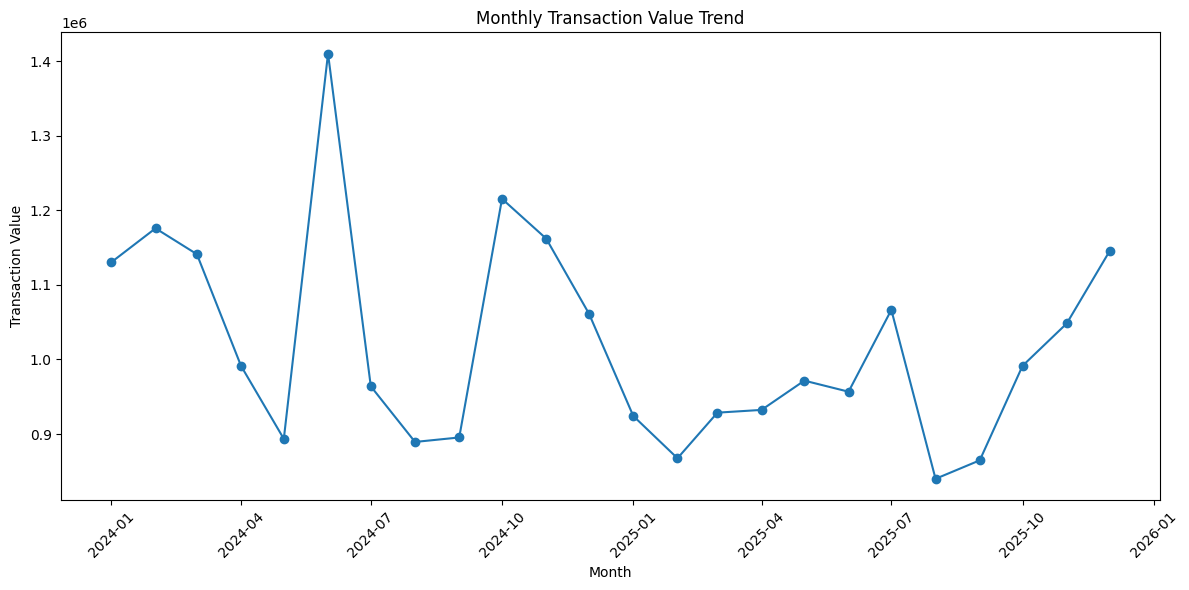

In [8]:
# Create the revenue trend
plt.figure(figsize=(12, 6))

plt.plot(
    df["month"],
    df["total_transaction_value"],
    marker="o"
)

plt.title("Monthly Transaction Value Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

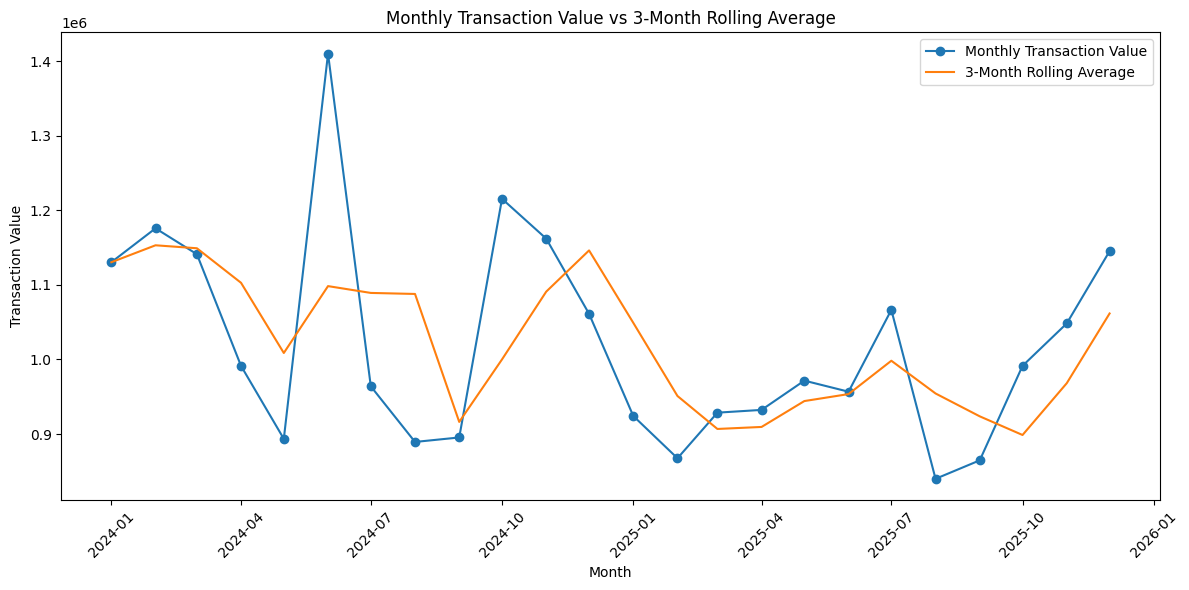

In [9]:
# compare the actual monthly value with the rolling average
plt.figure(figsize=(12, 6))

plt.plot(
    df["month"],
    df["total_transaction_value"],
    marker="o",
    label="Monthly Transaction Value"
)

plt.plot(
    df["month"],
    df["rolling_3_month_average"],
    label="3-Month Rolling Average"
)

plt.title("Monthly Transaction Value vs 3-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Transaction Value")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Analyze growth

df[
    [
        "month",
        "mom_growth_percent",
        "yoy_growth_percent"
    ]
].tail(12)

,month,mom_growth_percent,yoy_growth_percent
12,2025-01-01 00:00:00-05:00,-12.92,-18.25
13,2025-02-01 00:00:00-05:00,-6.14,-26.24
14,2025-03-01 00:00:00-05:00,7.06,-18.64
15,2025-04-01 00:00:00-04:00,0.40,-5.96
16,2025-05-01 00:00:00-04:00,4.21,8.75
17,2025-06-01 00:00:00-04:00,-1.53,-32.17
18,2025-07-01 00:00:00-04:00,11.48,10.65
19,2025-08-01 00:00:00-04:00,-21.26,-5.56
20,2025-09-01 00:00:00-04:00,2.95,-3.43
21,2025-10-01 00:00:00-04:00,14.67,-18.44


In [11]:
# identify the largest positive MoM changes
df[
    [
        "month",
        "mom_growth_percent"
    ]
].dropna().sort_values(
    "mom_growth_percent",
    ascending=False
).head(5)

,month,mom_growth_percent
5,2024-06-01 00:00:00-04:00,57.88
9,2024-10-01 00:00:00-04:00,35.78
21,2025-10-01 00:00:00-04:00,14.67
18,2025-07-01 00:00:00-04:00,11.48
23,2025-12-01 00:00:00-05:00,9.26


In [12]:
# largest declines
df[
    [
        "month",
        "mom_growth_percent"
    ]
].dropna().sort_values(
    "mom_growth_percent"
).head(5)

,month,mom_growth_percent
6,2024-07-01 00:00:00-04:00,-31.66
19,2025-08-01 00:00:00-04:00,-21.26
3,2024-04-01 00:00:00-04:00,-13.14
12,2025-01-01 00:00:00-05:00,-12.92
4,2024-05-01 00:00:00-04:00,-9.88


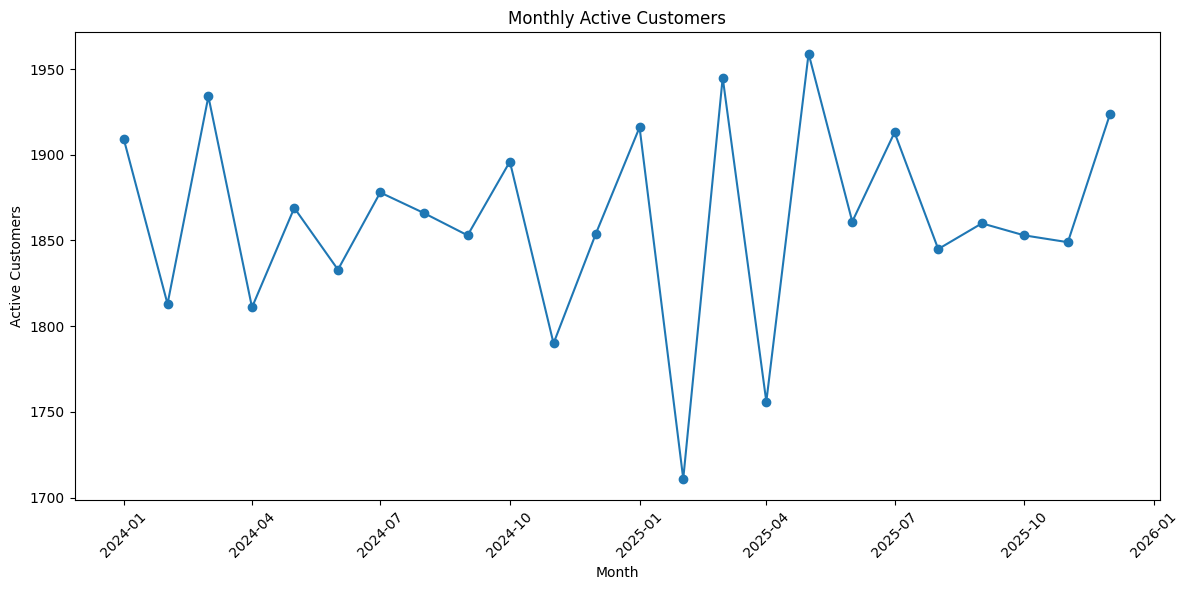

In [13]:
# Analyze active customers
plt.figure(figsize=(12, 6))

plt.plot(
    df["month"],
    df["active_customers"],
    marker="o"
)

plt.title("Monthly Active Customers")
plt.xlabel("Month")
plt.ylabel("Active Customers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
# Compare transaction value and active customers 
df[
    [
        "month",
        "total_transaction_value",
        "total_transactions",
        "active_customers",
        "average_transaction_value"
    ]
].tail(12)

,month,total_transaction_value,total_transactions,active_customers,average_transaction_value
12,2025-01-01 00:00:00-05:00,924220.25,2834,1916,326.12
13,2025-02-01 00:00:00-05:00,867438.80,2471,1711,351.05
14,2025-03-01 00:00:00-05:00,928645.89,2825,1945,328.72
15,2025-04-01 00:00:00-04:00,932341.94,2588,1756,360.26
16,2025-05-01 00:00:00-04:00,971630.78,2950,1959,329.37
17,2025-06-01 00:00:00-04:00,956773.27,2789,1861,343.05
18,2025-07-01 00:00:00-04:00,1066601.62,2841,1913,375.43
19,2025-08-01 00:00:00-04:00,839850.35,2783,1845,301.78
20,2025-09-01 00:00:00-04:00,864655.62,2800,1860,308.81
21,2025-10-01 00:00:00-04:00,991488.22,2798,1853,354.36


In [15]:
# Calculate transaction value per active customer
df["value_per_active_customer"] = (
    df["total_transaction_value"]
    / df["active_customers"]
)

In [16]:
df[
    [
        "month",
        "value_per_active_customer"
    ]
].tail(12)

,month,value_per_active_customer
12,2025-01-01 00:00:00-05:00,482.369650
13,2025-02-01 00:00:00-05:00,506.977674
14,2025-03-01 00:00:00-05:00,477.452900
15,2025-04-01 00:00:00-04:00,530.946435
16,2025-05-01 00:00:00-04:00,495.983042
17,2025-06-01 00:00:00-04:00,514.117824
18,2025-07-01 00:00:00-04:00,557.554428
19,2025-08-01 00:00:00-04:00,455.203442
20,2025-09-01 00:00:00-04:00,464.868613
21,2025-10-01 00:00:00-04:00,535.071894


In [17]:
# Find the highest-value months
top_months = (
    df[
        [
            "month",
            "total_transaction_value",
            "total_transactions",
            "active_customers"
        ]
    ]
    .sort_values(
        "total_transaction_value",
        ascending=False
    )
    .head(5)
)

top_months

,month,total_transaction_value,total_transactions,active_customers
5,2024-06-01 00:00:00-04:00,1410588.64,2736,1833
9,2024-10-01 00:00:00-04:00,1215672.46,2845,1896
1,2024-02-01 00:00:00-05:00,1176052.91,2690,1813
10,2024-11-01 00:00:00-04:00,1162216.67,2702,1790
23,2025-12-01 00:00:00-05:00,1145437.34,2856,1924


In [18]:
# Find the lowest-value months
bottom_months = (
    df[
        [
            "month",
            "total_transaction_value",
            "total_transactions",
            "active_customers"
        ]
    ]
    .sort_values(
        "total_transaction_value"
    )
    .head(5)
)

bottom_months

,month,total_transaction_value,total_transactions,active_customers
19,2025-08-01 00:00:00-04:00,839850.35,2783,1845
20,2025-09-01 00:00:00-04:00,864655.62,2800,1860
13,2025-02-01 00:00:00-05:00,867438.80,2471,1711
7,2024-08-01 00:00:00-04:00,889335.30,2806,1866
4,2024-05-01 00:00:00-04:00,893482.18,2780,1869


In [19]:
# Find strongest growth periods
growth_months = (
    df[
        [
            "month",
            "mom_growth_percent",
            "yoy_growth_percent"
        ]
    ]
    .dropna(subset=["mom_growth_percent"])
    .sort_values(
        "mom_growth_percent",
        ascending=False
    )
    .head(5)
)

growth_months

,month,mom_growth_percent,yoy_growth_percent
5,2024-06-01 00:00:00-04:00,57.88,NaN
9,2024-10-01 00:00:00-04:00,35.78,NaN
21,2025-10-01 00:00:00-04:00,14.67,-18.44
18,2025-07-01 00:00:00-04:00,11.48,10.65
23,2025-12-01 00:00:00-05:00,9.26,7.93


In [20]:
# Find largest declines
decline_months = (
    df[
        [
            "month",
            "mom_growth_percent",
            "yoy_growth_percent"
        ]
    ]
    .dropna(subset=["mom_growth_percent"])
    .sort_values(
        "mom_growth_percent"
    )
    .head(5)
)

decline_months

,month,mom_growth_percent,yoy_growth_percent
6,2024-07-01 00:00:00-04:00,-31.66,NaN
19,2025-08-01 00:00:00-04:00,-21.26,-5.56
3,2024-04-01 00:00:00-04:00,-13.14,NaN
12,2025-01-01 00:00:00-05:00,-12.92,-18.25
4,2024-05-01 00:00:00-04:00,-9.88,NaN


In [21]:
# Create an analyst-style summary table
summary = pd.DataFrame({
    "Metric": [
        "Average Monthly Transaction Value",
        "Average Monthly Transactions",
        "Average Monthly Active Customers",
        "Average Transaction Value"
    ],
    "Value": [
        df["total_transaction_value"].mean(),
        df["total_transactions"].mean(),
        df["active_customers"].mean(),
        df["average_transaction_value"].mean()
    ]
})

summary

,Metric,Value
0,Average Monthly Transaction Value,1.019532e+06
1,Average Monthly Transactions,2.778458e+03
2,Average Monthly Active Customers,1.862417e+03
3,Average Transaction Value,3.671458e+02
